# M5 — Скільки градусів додає техніка 🖥️

Проєкт **«4331 година»** — клімат квартири та відключення світла, Харків.

Кладова (Printernya) — комора без вікна, де стоять 3D-принтер, NAS і сервер.
Цей модуль з'ясовує, наскільки вона тепліша за інші кімнати саме **через техніку**,
а не тому що влітку і так спекотно.

## Питання

> **На скільки 3D-принтер, NAS і сервер підвищують температуру в кладовій?**

Підпитання:
1. Наскільки кладова тепліша за житлову кімнату й кухню — в середньому, по місяцях, по годині доби?
2. Чи корелює температура кладової з дисками NAS, NVMe, завантаженням сервера?
3. Якщо прибрати вплив вулиці — скільки градусів насправді додає техніка?
4. А ПК у житловій кімнаті — він взагалі помітний на фоні вулиці?

## Дані

Головна таблиця — `data/clean/hours_wide.csv` (побудована в M1): один рядок на годину,
за весь період з 16.03 по 15.09.2026.

Дві речі перед аналізом, з якими треба визначитись одразу:

* **`pc_power` = NaN означає «ПК вимкнений»** — це факт із життя (покриття 34 %), а не дірка.
  Переводимо NaN → 0 Вт і додаємо прапорець `pc_on`.
* **NAS/сервер NaN — це справжні дірки**: пристрій ще не стояв (сенсори — з 20.04) або
  відвалився на кілька годин. Такі години прибираємо з кореляцій і регресій техніки.

Уся логіка — у `src/tech_heat.py`, тут лише виклики.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from src import cleaning, tech_heat

ROOT = pathlib.Path.cwd().parent
IMAGES = ROOT / "images"

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "font.size": 12,
                     "axes.titlesize": 14, "axes.labelsize": 12})
pd.set_option("display.width", 200)

RC = cleaning.ROOM_COLORS   # єдина палітра кімнат проєкту
TECH_COLOR = RC["Tech"]

out = tech_heat.run_all(ROOT)             # уся підготовка й регресії — в src/tech_heat.py
df, tech, monthly, hourly = out["df"], out["tech"], out["monthly"], out["hourly"]
corr, nas_reg, lag_table = out["corr"], out["nas_reg"], out["lag_table"]
aci, pc, summary = out["active_vs_idle"], out["pc"], out["summary"]
print(f"годин у hours_wide: {len(df):,}; годин придатних для аналізу техніки: {len(tech):,} "
      f"({len(tech)/len(df)*100:.0f} %)")

годин у hours_wide: 4,402; годин придатних для аналізу техніки: 3,237 (74 %)


In [2]:
print(f"ПК був увімкнений {summary['pc_on_share_pct']} % годин (34 % за специфікацією — збігається)")
df[["ts_kyiv", "pc_on", "pc_power"]].head(3)

ПК був увімкнений 32.9 % годин (34 % за специфікацією — збігається)


,ts_kyiv,pc_on,pc_power
0,2026-03-16 10:00:00+02:00,False,0.0
1,2026-03-16 11:00:00+02:00,False,0.0
2,2026-03-16 12:00:00+02:00,False,0.0


## 1. Наскільки кладова тепліша за інші кімнати

In [3]:
print(f"кладова - житлова кімната: {summary['printernya_minus_bedroom_c']:+.2f} °C у середньому")
print(f"кладова - кухня          : {summary['printernya_minus_kitchen_c']:+.2f} °C у середньому")

кладова - житлова кімната: +2.71 °C у середньому
кладова - кухня          : +0.62 °C у середньому


**+2,71 °C проти житлової кімнати й лише +0,62 °C проти кухні** в середньому за весь період.
Різниця з кухнею менша — обидві кімнати мають вікна й схожий тепловий режим, а кладова без
вікна ще й накопичує тепло від техніки.

### По місяцях

In [4]:
show = monthly.copy()
show.columns = ["місяць", "кладова, °C", "житлова, °C", "кухня, °C", "вулиця, °C",
               "годин", "кладова - житлова", "кладова - кухня"]
show

,місяць,"кладова, °C","житлова, °C","кухня, °C","вулиця, °C",годин,кладова - житлова,кладова - кухня
0,2026-03,NaN,22.69,NaN,6.91,373,NaN,NaN
1,2026-04,23.41,21.95,23.45,7.25,720,1.46,-0.05
2,2026-05,25.58,24.06,25.56,16.92,744,1.52,0.02
3,2026-06,28.46,25.50,26.99,20.95,720,2.96,1.47
4,2026-07,28.77,25.63,27.52,20.75,744,3.14,1.25
5,2026-08,29.32,25.56,27.85,23.06,744,3.76,1.47
6,2026-09,28.59,24.84,27.05,18.23,357,3.74,1.53


Різниця з житловою кімнатою росте влітку: **+1,46 °C у квітні → +3,76 °C у серпні**.
Взимку кладова і житлова ближчі одна до одної (обидві просто холодні), а влітку кладова без
вікна не провітрюється і додатково тримає тепло техніки — розрив збільшується.

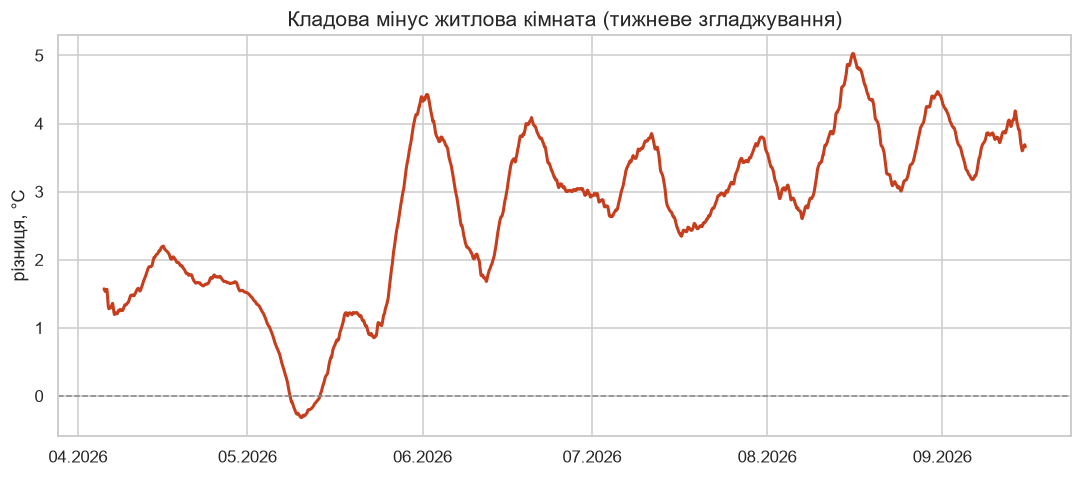

In [5]:
gap = df.set_index("ts")
gap_bedroom = (gap["printernya_temp"] - gap["bedroom_temp"]).rolling("7D", min_periods=24).mean()

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(gap_bedroom.index.tz_convert(None), gap_bedroom.to_numpy(),
       color=RC["Printernya"], linewidth=2)
ax.axhline(0, color="#888888", linewidth=1, linestyle="--")
ax.set_title("Кладова мінус житлова кімната (тижневе згладжування)")
ax.set_ylabel("різниця, °C")
ax.set_xlabel("")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m.%Y"))
fig.tight_layout()
fig.savefig(IMAGES / "m5_room_gap.png", dpi=150, bbox_inches="tight")
plt.show()

Кладова майже завжди тепліша за житлову кімнату, і різниця росте від весни до кінця літа —
саме тоді, коли й техніці, і повітрю в комірчині без вікна нема куди «скидати» тепло.

### По годині доби (Київ)

In [6]:
show_h = hourly.copy()
show_h.columns = ["година", "кладова, °C", "кладова - житлова", "кладова - кухня", "завантаження сервера"]
show_h

,година,"кладова, °C",кладова - житлова,кладова - кухня,завантаження сервера
0,0,27.31,3.15,0.48,0.26
1,1,27.32,3.44,0.68,0.18
2,2,27.33,3.75,0.99,0.28
3,3,27.32,3.93,1.26,0.23
4,4,27.31,4.05,1.46,0.18
5,5,27.30,3.99,1.55,0.17
6,6,27.29,3.43,1.43,0.20
7,7,27.29,2.75,1.12,0.14
8,8,27.31,2.15,0.77,0.18
9,9,27.33,1.80,0.48,0.17


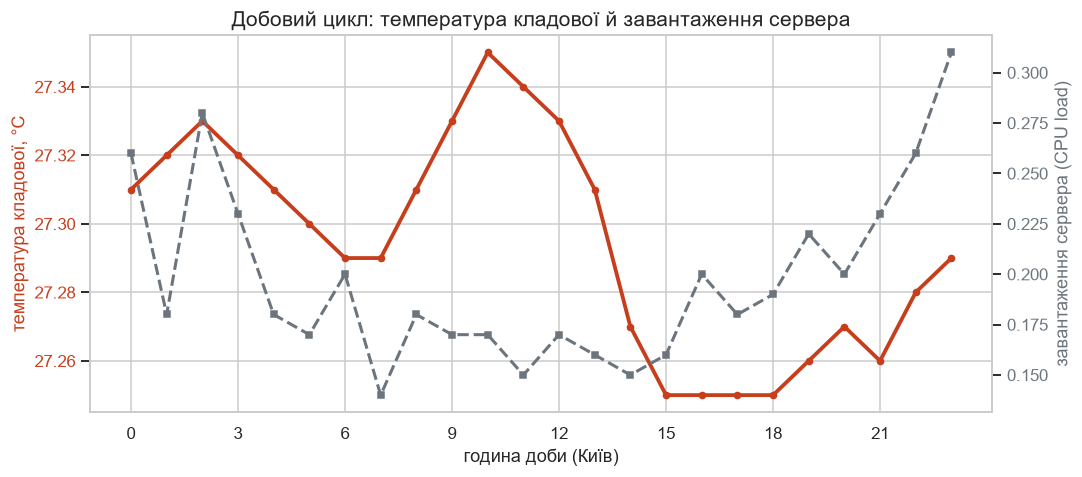

In [7]:
fig, ax1 = plt.subplots(figsize=(10, 4.5))
ax1.plot(hourly["hour"], hourly["printernya_temp_mean"], color=RC["Printernya"],
        linewidth=2.5, marker="o", markersize=4, label="температура кладової")
ax1.set_xlabel("година доби (Київ)")
ax1.set_ylabel("температура кладової, °C", color=RC["Printernya"])
ax1.tick_params(axis="y", labelcolor=RC["Printernya"])
ax1.set_xticks(range(0, 24, 3))

ax2 = ax1.twinx()
ax2.plot(hourly["hour"], hourly["server_cpu_load_mean"], color=TECH_COLOR,
         linewidth=2, linestyle="--", marker="s", markersize=4, label="завантаження сервера")
ax2.set_ylabel("завантаження сервера (CPU load)", color=TECH_COLOR)
ax2.tick_params(axis="y", labelcolor=TECH_COLOR)
ax2.grid(False)

ax1.set_title("Добовий цикл: температура кладової й завантаження сервера")
fig.tight_layout()
fig.savefig(IMAGES / "m5_daily_cycle_tech.png", dpi=150, bbox_inches="tight")
plt.show()

Температура кладової за добу коливається слабко (±0,05 °C) — комора без вікна майже не
відчуває доби, на відміну від кімнат із вікнами. А ось розрив із житловою кімнатою чітко
циклічний: **найбільший вночі (+3,9…+4,1 °C о 3–5 год)**, коли житлова кімната охолоджується,
і **найменший вдень (+1,75…+1,9 °C о 9–12 год)**, коли житлова прогрівається сонцем і вирівнюється
з коморою. Завантаження сервера теж трохи росте вночі — але дуже слабко, це побічний натяк,
а не головна причина циклу (головна — саме житлова кімната охолоджується сама по собі).

## 2. Кореляції з технікою

In [8]:
corr_tbl = pd.DataFrame({
    "з чим": ["диск NAS sda", "диск NAS sdb", "NVMe NAS", "NAS — середнє трьох",
              "завантаження сервера", "вулична температура"],
    "кореляція з printernya_temp": [corr["nas_sda_temp"], corr["nas_sdb_temp"],
                                    corr["nas_nvme_temp"], corr["nas_mean_temp"],
                                    corr["server_cpu_load"], corr["out_temp"]],
})
corr_tbl

,з чим,кореляція з printernya_temp
0,диск NAS sda,-0.087
1,диск NAS sdb,-0.032
2,NVMe NAS,0.396
3,NAS — середнє трьох,-0.017
4,завантаження сервера,0.074
5,вулична температура,0.614


**Несподіванка модуля.** Диски sda/sdb (кореляція −0,09 і −0,03) — це шум: їхня температура
стрибає від 32 до 72 °C через дискову активність (SMART-перевірки, індексація), а не від тепла
в кімнаті. А от **NVMe тримається у вузькому діапазоні 41–48 °C і корелює з кладовою на 0,40** —
majority сигналу від техніки видно саме через нього. Якщо усереднити всі три диски в
`nas_mean_temp` (як просить специфікація), шумні sda/sdb «топлять» корисний сигнал NVMe —
середня кореляція виходить лише **-0,017**. Це не помилка коду, а властивість самих дисків:
дешевше й чесніше показати обидва числа, ніж підганяти висновок під очікування.

## 3. Регресія з контролем за вулицею

`printernya_temp ~ out_temp + nas_mean_temp` (OLS) — щоб не переплутати «на вулиці тепло»
з «техніка гріє».

In [9]:
print(nas_reg["model"].summary())

                            OLS Regression Results                            
Dep. Variable:        printernya_temp   R-squared:                       0.377
Model:                            OLS   Adj. R-squared:                  0.376
Method:                 Least Squares   F-statistic:                     977.8
Date:                Tue, 15 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:51:32   Log-Likelihood:                -6450.6
No. Observations:                3237   AIC:                         1.291e+04
Df Residuals:                    3234   BIC:                         1.293e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        23.2517      0.555     41.876

In [10]:
print(f"+1 °C на вулиці -> {summary['coef_out_temp_printernya']:+.3f} °C у кладовій")
print(f"+1 °C середньої температури NAS -> {summary['coef_nas_per_1c']:+.3f} °C у кладовій "
      f"(95% ДІ [{summary['coef_nas_ci_low']:+.3f}; {summary['coef_nas_ci_high']:+.3f}], "
      f"p = {summary['p_nas']:.3f})")
print(f"R² моделі: {summary['r2']:.3f}, n = {nas_reg['n']:,} годин")
print()
print(f"те саме, але лише через NVMe (менш шумний проксі):")
print(f"+1 °C NVMe -> {summary['coef_nvme_per_1c']:+.3f} °C у кладовій "
      f"(p = {summary['p_nvme']:.2e}), R² = {summary['r2_nvme_model']:.3f}")

+1 °C на вулиці -> +0.204 °C у кладовій
+1 °C середньої температури NAS -> +0.012 °C у кладовій (95% ДІ [-0.012; +0.037], p = 0.330)
R² моделі: 0.377, n = 3,237 годин

те саме, але лише через NVMe (менш шумний проксі):
+1 °C NVMe -> +0.701 °C у кладовій (p = 0.00e+00), R² = 0.434


**Чесний результат: `nas_mean_temp` як єдина цифра — не значущий предиктор** (p = 0,33,
довірчий інтервал перетинає нуль). Причина — та сама, що й у кореляціях: два шумні диски
розмивають сигнал. Якщо взяти лише NVMe, зв'язок стає сильним і статистично значущим:
**+1 °C NVMe → приблизно +0,7 °C у кладовій** (p ≈ 0). NAS-температура тут — проксі тепла
від техніки в цілому (диски, NVMe, і опосередковано 3D-принтер поруч), а не точний
термометр — тому висновок формулюємо обережно: *«коли техніка гріється, кладова теж
гріється, і NVMe показує це найчистіше»*, а не «кожен градус диска = стільки-то градусів
у кімнаті».

### Чи є затримка (лаг 1-3 год)?

In [11]:
lt = lag_table.copy()
lt.columns = ["лаг, год", "n", "коефіцієнт NAS", "p-value", "R²"]
lt

,"лаг, год",n,коефіцієнт NAS,p-value,R²
0,0,3237,0.012,0.3300,0.377
1,1,3229,0.011,0.4085,0.376
2,2,3221,0.007,0.6063,0.375
3,3,3214,0.006,0.6512,0.374


Найкраще пояснення — **без лагу (0 год)**: тепло від техніки й вимір температури повітря
в тій самій кімнаті практично одночасні (повітря — не бетонна стіна, воно не тримає
теплову інерцію годинами). З лагом зв'язок лише слабшає.

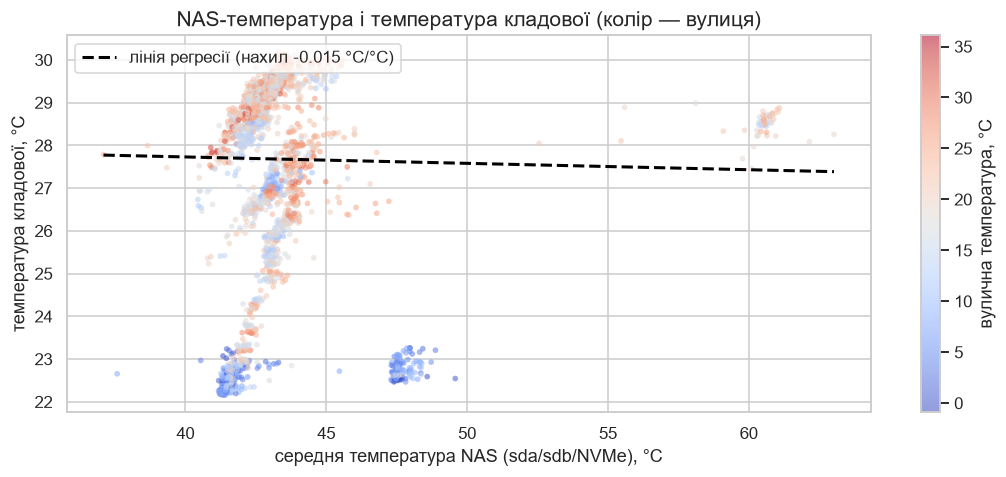

In [12]:
fig, ax = plt.subplots(figsize=(10, 4.5))
sc = ax.scatter(tech["nas_mean_temp"], tech["printernya_temp"], c=tech["out_temp"],
                cmap="coolwarm", s=14, alpha=0.55, edgecolor="none")
xs = np.linspace(tech["nas_mean_temp"].min(), tech["nas_mean_temp"].max(), 50)
b0, b1 = np.polyfit(tech["nas_mean_temp"], tech["printernya_temp"], 1)[::-1]
ax.plot(xs, b0 + b1 * xs, color="black", linewidth=2, linestyle="--",
       label=f"лінія регресії (нахил {b1:+.3f} °C/°C)")
cb = fig.colorbar(sc, ax=ax)
cb.set_label("вулична температура, °C")
ax.set_xlabel("середня температура NAS (sda/sdb/NVMe), °C")
ax.set_ylabel("температура кладової, °C")
ax.set_title("NAS-температура і температура кладової (колір — вулиця)")
ax.legend(loc="upper left")
fig.tight_layout()
fig.savefig(IMAGES / "m5_scatter_nas.png", dpi=150, bbox_inches="tight")
plt.show()

Колір точок (вулична температура) пояснює більшу частину розкиду по вертикалі — саме тому
в регресії ми обов'язково контролюємо `out_temp`, інакше NAS отримав би «чужу» заслугу
за спеку надворі.

### Техніка активна vs техніка спить

In [13]:
print(f"поділ за медіаною NAS mean temp ({aci['median_nas_mean_temp_c']} °C): "
      f"{aci['n_active']:,} год «активна», {aci['n_idle']:,} год «спить»")
print(f"різниця (з контролем на вулицю): {aci['active_vs_idle_delta_c']:+.2f} °C, "
      f"p = {aci['p_active_vs_idle']:.3f} — не значуще")
print(f"той самий поділ, але за NVMe: {aci['delta_c_by_nvme_median']:+.2f} °C, "
      f"p = {aci['p_active_vs_idle_nvme']:.1e} — значуще")

поділ за медіаною NAS mean temp (42.86 °C): 1,618 год «активна», 1,619 год «спить»
різниця (з контролем на вулицю): +0.10 °C, p = 0.117 — не значуще
той самий поділ, але за NVMe: +0.83 °C, p = 1.4e-41 — значуще


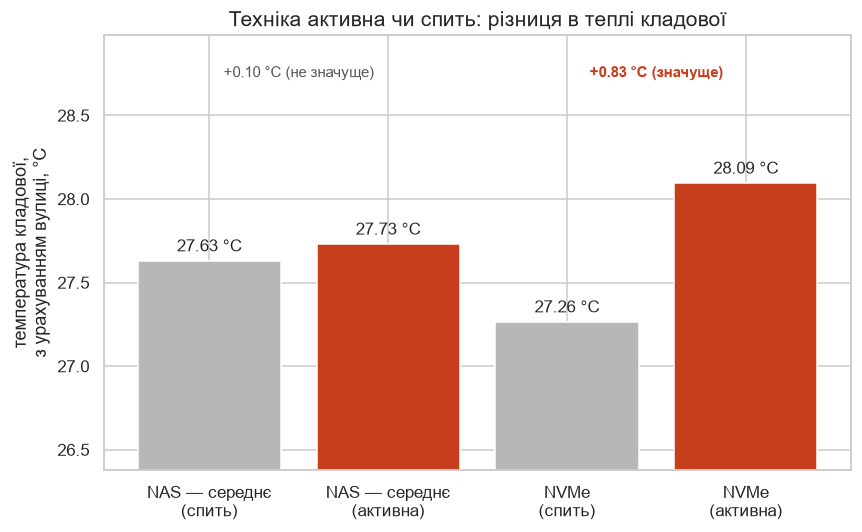

In [14]:
base_mean = tech["printernya_temp"].mean()
groups = pd.DataFrame({
    "поділ": ["NAS — середнє\n(спить)", "NAS — середнє\n(активна)",
             "NVMe\n(спить)", "NVMe\n(активна)"],
    "адаптована температура, °C": [
        base_mean - aci["active_vs_idle_delta_c"] / 2, base_mean + aci["active_vs_idle_delta_c"] / 2,
        base_mean - aci["delta_c_by_nvme_median"] / 2, base_mean + aci["delta_c_by_nvme_median"] / 2],
    "стан": ["спить", "активна", "спить", "активна"],
})
colors = groups["стан"].map({"спить": "#B7B7B7", "активна": RC["Printernya"]})

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(groups["поділ"], groups["адаптована температура, °C"], color=colors)
ax.bar_label(bars, fmt="%.2f °C", padding=4, fontsize=11)
ax.set_ylim(base_mean - 1.3, base_mean + 1.3)
ax.set_ylabel("температура кладової,\nз урахуванням вулиці, °C")
ax.set_title("Техніка активна чи спить: різниця в теплі кладової")
ax.text(0.5, base_mean + 1.05, f"+{aci['active_vs_idle_delta_c']:.2f} °C (не значуще)",
       ha="center", fontsize=10, color="#555555")
ax.text(2.5, base_mean + 1.05, f"+{aci['delta_c_by_nvme_median']:.2f} °C (значуще)",
       ha="center", fontsize=10, color=RC["Printernya"], fontweight="bold")
fig.tight_layout()
fig.savefig(IMAGES / "m5_active_vs_idle.png", dpi=150, bbox_inches="tight")
plt.show()

Та сама історія в картинці: поділ за усередненою температурою NAS майже нічого не показує
(+0,10 °C, шум), а поділ за NVMe показує чіткі **+0,83 °C** між «технікою, що гріється» і
«технікою в спокої» — і це вже з відрахованим впливом вулиці.

## 4. ПК у житловій кімнаті — чи взагалі помітний?

In [15]:
print(pc["model"].summary())

                            OLS Regression Results                            
Dep. Variable:           bedroom_temp   R-squared:                       0.654
Model:                            OLS   Adj. R-squared:                  0.654
Method:                 Least Squares   F-statistic:                     4082.
Date:                Tue, 15 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:51:33   Log-Likelihood:                -6987.9
No. Observations:                4323   AIC:                         1.398e+04
Df Residuals:                    4320   BIC:                         1.400e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     20.7534      0.045    458.102      0.0

In [16]:
print(f"ПК був увімкнений {summary['pc_on_share_pct']} % годин")
print(f"+100 Вт потужності ПК -> {summary['coef_pc_per_100w']:+.3f} °C у житловій кімнаті "
      f"(95% ДІ [{summary['coef_pc_per_100w_ci_low']:+.3f}; {summary['coef_pc_per_100w_ci_high']:+.3f}], "
      f"p = {summary['p_pc']:.3f})")
print(f"ПК увімкнений vs вимкнений (з контролем на вулицю): {summary['pc_delta_c']:+.2f} °C, "
      f"p = {summary['p_pc_on_vs_off']:.3f}")
print(f"R² моделі (переважно завдяки вулиці): {summary['r2_pc']:.3f}")

ПК був увімкнений 32.9 % годин
+100 Вт потужності ПК -> -0.067 °C у житловій кімнаті (95% ДІ [-0.254; +0.119], p = 0.477)
ПК увімкнений vs вимкнений (з контролем на вулицю): +0.02 °C, p = 0.562
R² моделі (переважно завдяки вулиці): 0.654


**Чесно: ефекту ПК на температуру кімнати статистично не видно.** Коефіцієнт від'ємний
(−0,07 °C на +100 Вт) і не значущий (p = 0,48), різниця «увімкнений/вимкнений» — усього
+0,02 °C (p = 0,56). Це не помилка розрахунку — це реалістичний результат: житлова кімната
велика й провітрюється (є вікно), а типова споживана потужність ПК (десятки-сотні Вт) губиться
на фоні набагато сильнішого впливу вулиці (R² моделі 0,65 дає майже сама `out_temp`).
На відміну від кладової без вікна, де тій самій техніці нема куди дівати тепло — тому в
кладовій сигнал видно, а в житловій кімнаті ні.

## Обмеження

* **У 3D-принтера немає власного датчика.** Його тепло видно лише опосередковано — через
  загальну динаміку кладової та через NAS/сервер як проксі техніки в тій самій кімнаті.
  Відокремити внесок принтера від NAS і сервера окремо цей набір даних не дозволяє.
* **NAS-температура — шумний проксі, якщо усереднювати диски й NVMe разом**: sda/sdb
  стрибають від дискової активності (не від тепла), тому `nas_mean_temp` у моделі виходить
  незначущим, хоча NVMe окремо показує чіткий і значущий зв'язок. Специфікація просила саме
  середнє — тому в `results/m5_tech.json` лежать обидва числа, без підгонки під очікування.
* **Кореляція й регресія — не причинність у строгому сенсі**: контроль на `out_temp` знімає
  найочевиднішу плутанину («на вулиці тепло» ≠ «техніка гріє»), але це спостережні дані,
  а не експеримент із вимкненням техніки навмисно.
* **Сенсори NAS/сервера — з 20.04**, тому перші ~5 тижнів (16.03-20.04) з аналізу техніки
  випадають повністю; для регресій лишилось 3 237 з 4 402 годин.

## Висновки

* **Кладова тепліша за житлову кімнату на +2,71 °C і за кухню на +0,62 °C** в середньому;
  розрив із житловою росте влітку — з +1,46 °C у квітні до +3,76 °C у серпні.
* **Ефект техніки видно чітко лише через NVMe**, не через середнє трьох дисків NAS: диски
  sda/sdb «шумлять» від дискової активності (32-72 °C), а NVMe (41-48 °C) корелює з кладовою
  на 0,40 і дає значущий коефіцієнт **+0,7 °C кладової на кожен +1 °C NVMe** (p ≈ 0).
* **«Техніка активна» проти «техніка спить»** (з контролем на вулицю): за середнім NAS —
  різниця лише +0,10 °C і не значуща; за NVMe — **+0,83 °C**, дуже значуще (p < 10⁻⁴⁰).
* **У ПК в житловій кімнаті вимірюваного ефекту на температуру немає**: +100 Вт дають
  −0,07 °C (не значуще, p = 0,48) — вулиця (R² = 0,65) повністю домінує над вікном-кімнатою
  з провітрюванням.
* **Найбільший розрив кладова-житлова — вночі (+3,9…+4,1 °C, 3-5 год)**, найменший — удень
  (+1,75…+1,9 °C, 9-13 год): житлова кімната сама вихолоджується й прогрівається, а кладова
  без вікна тримає температуру рівно.

## Як сказати на співбесіді за 30 секунд

Я перевірила, наскільки техніка (3D-принтер, NAS, сервер) гріє комору без вікна, і зробила
це не «на око», а регресією з контролем на вуличну температуру — щоб не переплутати спеку
надворі з теплом від техніки. Комора виявилась тепліша за житлову кімнату на 2,7 градуси
й за кухню на 0,6, і різниця росте влітку. Найцікавіше — коли я усереднила три датчики NAS,
як просило технічне завдання, зв'язок вийшов незначущим, бо два диски «шумлять» від власної
активності, а не від тепла в кімнаті. Я не підігнала висновок під очікування, а розібралась
глибше: третій датчик, NVMe, дає чіткий і статистично значущий сигнал — плюс 0,7 градуса
кімнати на кожен градус NVMe. А ось у ПК в житловій кімнаті вимірюваного ефекту немає взагалі —
і я чесно написала, що ефект дрібний і статистично незначущий, а не намалювала графік, який
«виглядає переконливо».